Step 1: Understanding the Machine Learning Problem

In [90]:
# Load dataset and check file availability
import pandas as pd
from pathlib import Path

file_name = "insurance_policy_renewal_dataset.xls"
data_path = Path(file_name)

print("Current dataset path:", data_path)

print("File exists:", data_path.exists())
df = pd.read_csv(data_path)

print("Dataset loaded successfully!")

df.head()

Current dataset path: insurance_policy_renewal_dataset.xls
File exists: True
Dataset loaded successfully!


,Customer_ID,Age,Policy_Type,Annual_Premium,Years_With_Company,Number_of_Claims,Claim_Amount_Last_Year,Payment_Method,Customer_Service_Calls,Satisfaction_Score,Received_Discount,Auto_Renew_Enabled,Renewed_Policy
0,1,29.0,Auto,3250.0,9,4,1006,Credit Card,1,3.0,No,Yes,Yes
1,2,48.0,Health,2514.0,10,4,5228,Credit Card,10,2.0,No,No,No
2,3,41.0,Life,4760.0,3,2,13296,Credit Card,3,2.0,No,Yes,No
3,4,56.0,Auto,5849.0,4,3,11569,Bank Transfer,4,1.0,No,NaN,No
4,5,71.0,Health,4589.0,12,0,8274,Bank Transfer,5,4.0,No,Yes,Yes


In [91]:
# Define the target column that we want to predict
target_column = "Renewed_Policy"  
print("Target column:")
print(target_column)
print("\nTarget values:")
print(df[target_column].value_counts())

Target column:
Renewed_Policy

Target values:
Renewed_Policy
No     235
Yes    111
Name: count, dtype: int64


In [92]:
# Identify the features and target variable
# Define x and y

# Define the feature columns
feature_columns = [
    "Age",
    "Policy_Type",
    "Annual_Premium",
    "Years_With_Company",
    "Number_of_Claims",
    "Claim_Amount_Last_Year",
    "Payment_Method",
    "Customer_Service_Calls",
    "Satisfaction_Score",
    "Received_Discount",
    "Auto_Renew_Enabled"
]

X = df[feature_columns]
y = df[target_column]

print("Feature columns:")
print(feature_columns)

print("\nTarget column:")
print(target_column)

print("\nShape of X:")
print(X.shape)

print("\nShape of y:")
print(y.shape)

Feature columns:
['Age', 'Policy_Type', 'Annual_Premium', 'Years_With_Company', 'Number_of_Claims', 'Claim_Amount_Last_Year', 'Payment_Method', 'Customer_Service_Calls', 'Satisfaction_Score', 'Received_Discount', 'Auto_Renew_Enabled']

Target column:
Renewed_Policy

Shape of X:
(346, 11)

Shape of y:
(346,)


Step 2: Data Preparation and Initial Data Inspection

In [93]:
# Show the number of rows and columns in the dataset
print("Dataset shape:")
print(df.shape)  

print("\nColumn names:")
print(df.columns.tolist())

print("\nFirst five rows of the dataset:")  
display(df.head())

Dataset shape:
(346, 13)

Column names:
['Customer_ID', 'Age', 'Policy_Type', 'Annual_Premium', 'Years_With_Company', 'Number_of_Claims', 'Claim_Amount_Last_Year', 'Payment_Method', 'Customer_Service_Calls', 'Satisfaction_Score', 'Received_Discount', 'Auto_Renew_Enabled', 'Renewed_Policy']

First five rows of the dataset:


,Customer_ID,Age,Policy_Type,Annual_Premium,Years_With_Company,Number_of_Claims,Claim_Amount_Last_Year,Payment_Method,Customer_Service_Calls,Satisfaction_Score,Received_Discount,Auto_Renew_Enabled,Renewed_Policy
0,1,29.0,Auto,3250.0,9,4,1006,Credit Card,1,3.0,No,Yes,Yes
1,2,48.0,Health,2514.0,10,4,5228,Credit Card,10,2.0,No,No,No
2,3,41.0,Life,4760.0,3,2,13296,Credit Card,3,2.0,No,Yes,No
3,4,56.0,Auto,5849.0,4,3,11569,Bank Transfer,4,1.0,No,NaN,No
4,5,71.0,Health,4589.0,12,0,8274,Bank Transfer,5,4.0,No,Yes,Yes


In [94]:
# Show dataset information
print("Dataset information:")
df.info()  # Show column names, non-null values, and data types

Dataset information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 346 entries, 0 to 345
Data columns (total 13 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Customer_ID             346 non-null    int64  
 1   Age                     338 non-null    float64
 2   Policy_Type             340 non-null    object 
 3   Annual_Premium          340 non-null    float64
 4   Years_With_Company      346 non-null    int64  
 5   Number_of_Claims        346 non-null    int64  
 6   Claim_Amount_Last_Year  346 non-null    int64  
 7   Payment_Method          339 non-null    object 
 8   Customer_Service_Calls  346 non-null    int64  
 9   Satisfaction_Score      340 non-null    float64
 10  Received_Discount       346 non-null    object 
 11  Auto_Renew_Enabled      340 non-null    object 
 12  Renewed_Policy          346 non-null    object 
dtypes: float64(3), int64(5), object(5)
memory usage: 35.3+ KB


In [95]:
# Check missing values in each column
print("Missing values in each column:")
print(df.isnull().sum())

Missing values in each column:
Customer_ID               0
Age                       8
Policy_Type               6
Annual_Premium            6
Years_With_Company        0
Number_of_Claims          0
Claim_Amount_Last_Year    0
Payment_Method            7
Customer_Service_Calls    0
Satisfaction_Score        6
Received_Discount         0
Auto_Renew_Enabled        6
Renewed_Policy            0
dtype: int64


In [96]:
# Check duplicate rows
print("Number of duplicate rows:")
print(df.duplicated().sum())

Number of duplicate rows:
6


Step 3: Data Cleaning

In [97]:
# Create a copy of the original dataset before cleaning
df_clean = df.copy()

print("Original dataset shape:")
print(df_clean.shape)

print("\nNumber of duplicate rows before cleaning:")
print(df_clean.duplicated().sum())

Original dataset shape:
(346, 13)

Number of duplicate rows before cleaning:
6


In [98]:
# Remove duplicate rows from the dataset
df_clean = df_clean.drop_duplicates()  

print("Dataset shape after removing duplicate rows:")
print(df_clean.shape)

print("\nNumber of duplicate rows after cleaning:")
print(df_clean.duplicated().sum())

Dataset shape after removing duplicate rows:
(340, 13)

Number of duplicate rows after cleaning:
0


In [99]:
# Recheck count of missing values in each columns
print("Missing values before filling:")
print(df_clean.isnull().sum())

Missing values before filling:
Customer_ID               0
Age                       6
Policy_Type               6
Annual_Premium            6
Years_With_Company        0
Number_of_Claims          0
Claim_Amount_Last_Year    0
Payment_Method            6
Customer_Service_Calls    0
Satisfaction_Score        6
Received_Discount         0
Auto_Renew_Enabled        6
Renewed_Policy            0
dtype: int64


In [100]:
# Fill numerical missing values with the median value
numerical_columns_to_fill = ["Age", "Annual_Premium", "Satisfaction_Score"]
for col in numerical_columns_to_fill:
    df_clean[col] = df_clean[col].fillna(df_clean[col].median())

# Fill categorical missing values with the most frequent value using mode()[0]
categorical_columns_to_fill = ["Policy_Type", "Payment_Method", "Auto_Renew_Enabled"]
for col in categorical_columns_to_fill:
    df_clean[col] = df_clean[col].fillna(df_clean[col].mode()[0])

In [101]:
# Count missing values in each column after cleaning
print("Missing values after cleaning:") 
print(df_clean.isnull().sum())  

# Display the first five rows of the cleaned dataset
print("\nCleaned dataset preview:")
display(df_clean.head())  

Missing values after cleaning:
Customer_ID               0
Age                       0
Policy_Type               0
Annual_Premium            0
Years_With_Company        0
Number_of_Claims          0
Claim_Amount_Last_Year    0
Payment_Method            0
Customer_Service_Calls    0
Satisfaction_Score        0
Received_Discount         0
Auto_Renew_Enabled        0
Renewed_Policy            0
dtype: int64

Cleaned dataset preview:


,Customer_ID,Age,Policy_Type,Annual_Premium,Years_With_Company,Number_of_Claims,Claim_Amount_Last_Year,Payment_Method,Customer_Service_Calls,Satisfaction_Score,Received_Discount,Auto_Renew_Enabled,Renewed_Policy
0,1,29.0,Auto,3250.0,9,4,1006,Credit Card,1,3.0,No,Yes,Yes
1,2,48.0,Health,2514.0,10,4,5228,Credit Card,10,2.0,No,No,No
2,3,41.0,Life,4760.0,3,2,13296,Credit Card,3,2.0,No,Yes,No
3,4,56.0,Auto,5849.0,4,3,11569,Bank Transfer,4,1.0,No,Yes,No
4,5,71.0,Health,4589.0,12,0,8274,Bank Transfer,5,4.0,No,Yes,Yes


Step 4: Feature and Target Definition Using Cleaned Dataset

In [102]:
feature_columns = [
    "Age",
    "Policy_Type",
    "Annual_Premium",
    "Years_With_Company",
    "Number_of_Claims",
    "Claim_Amount_Last_Year",
    "Payment_Method",
    "Customer_Service_Calls",
    "Satisfaction_Score",
    "Received_Discount",
    "Auto_Renew_Enabled"
]

target_column = "Renewed_Policy"

X = df_clean[feature_columns]
y = df_clean[target_column]

# Print the list of feature columns
print("Feature columns:")
print(feature_columns)  

# Print the target column name
print("\nTarget column:")
print(target_column)  

# Show the number of rows and columns in X
print("\nShape of X:")
print(X.shape)  

# Show the number of values in y
print("\nShape of y:")
print(y.shape)

Feature columns:
['Age', 'Policy_Type', 'Annual_Premium', 'Years_With_Company', 'Number_of_Claims', 'Claim_Amount_Last_Year', 'Payment_Method', 'Customer_Service_Calls', 'Satisfaction_Score', 'Received_Discount', 'Auto_Renew_Enabled']

Target column:
Renewed_Policy

Shape of X:
(340, 11)

Shape of y:
(340,)


In [103]:
# Count how many Yes and No values are in the target variable
print("Target value counts before conversion:")
print(y.value_counts())

Target value counts before conversion:
Renewed_Policy
No     233
Yes    107
Name: count, dtype: int64


In [104]:
# Convert target labels from text to numbers
y = y.map({"No": 0, "Yes": 1})

print("Target value counts after conversion:")
print(y.value_counts())

Target value counts after conversion:
Renewed_Policy
0    233
1    107
Name: count, dtype: int64


Step 5: Train/Test Split

In [105]:
# Import train_test_split from scikit-learn
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("X_train shape:\n", X_train.shape)
print("X_test shape:\n", X_test.shape)
print("y_train shape:\n", y_train.shape)
print("y_test shape:\n", y_test.shape)

X_train shape:
 (272, 11)
X_test shape:
 (68, 11)
y_train shape:
 (272,)
y_test shape:
 (68,)


In [106]:
# Count the number of 0 and 1 values in target train data
print("Target distribution in y_train:")
print(y_train.value_counts())  

# Count the number of 0 and 1 values in target test data
print("\nTarget distribution in y_test:")
print(y_test.value_counts())  

Target distribution in y_train:
Renewed_Policy
0    186
1     86
Name: count, dtype: int64

Target distribution in y_test:
Renewed_Policy
0    47
1    21
Name: count, dtype: int64


Step 6: Preprocessing

In [107]:
# Import ColumnTransformer to apply different preprocessing steps to different columns
from sklearn.compose import ColumnTransformer

# Import OneHotEncoder for categorical variables
# Import StandardScaler for numerical variables
from sklearn.preprocessing import OneHotEncoder, StandardScaler

numeric_features = [
    "Age",
    "Annual_Premium",
    "Years_With_Company",
    "Number_of_Claims",
    "Claim_Amount_Last_Year",
    "Customer_Service_Calls",
    "Satisfaction_Score",
]

categorical_features = [
    "Policy_Type",
    "Payment_Method",
    "Received_Discount",
    "Auto_Renew_Enabled"
]

preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numerical_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features)
    ]
)

In [108]:
# Fit the preprocessor on the training data and transform X_train
X_train_preprocessed = preprocessor.fit_transform(X_train)
print("X_train preprocessing completed!")

X_train preprocessing completed!


In [109]:
# Fit the preprocessor on the training data and transform X_test
X_test_preprocessed = preprocessor.transform(X_test)
print("X_test preprocessing completed!")

X_test preprocessing completed!


In [110]:
 # Show the number of rows and columns in X_train and X_test before and after preprocessing
print("Summary of preprocessing shapes:")
print("X_train before preprocessing:", X_train.shape)
print("X_train after preprocessing:", X_train_preprocessed.shape)
print("X_test before preprocessing:", X_test.shape)
print("X_test after preprocessing:", X_test_preprocessed.shape)

Summary of preprocessing shapes:
X_train before preprocessing: (272, 11)
X_train after preprocessing: (272, 18)
X_test before preprocessing: (68, 11)
X_test after preprocessing: (68, 18)


Task 1: Train and compare two classification models

Step 7: Building a Baseline Model with Logistic Regression

In [111]:
# Import Logistic Regression from scikit-learn
from sklearn.linear_model import LogisticRegression

In [112]:
# Create a Logistic Regression model
logistic_model = LogisticRegression(max_iter=1000, random_state=42)

In [113]:
# Train the Logistic Regression model using the preprocessed training data
logistic_model.fit(X_train_preprocessed, y_train) 
print("Logistic Regression model trained successfully!")

Logistic Regression model trained successfully!


In [114]:
# Use the trained model to make predictions on the processed test data
y_pred_logistic = logistic_model.predict(X_test_processed)

print("Predictions completed successfully!")

Predictions completed successfully!


In [115]:
# Printing predictions using Logistic Regression model
print("Logistic Regression: First 10 predictions:") 

print(y_pred_logistic[:10])

Logistic Regression: First 10 predictions:
[1 1 0 1 0 0 0 0 0 0]


In [116]:
# Create a DataFrame to compare actual and predicted values using logistic regression model
comparison_df = pd.DataFrame({  
    "Actual": y_test.values,  
    "Predicted": y_pred_logistic
})

display(comparison_df.head(10))

,Actual,Predicted
0,1,1
1,1,1
2,0,0
3,0,1
4,0,0
5,0,0
6,0,0
7,0,0
8,0,0
9,0,0


Step 8: Evaluating the Logistic Regression Model

In [117]:
# Import evaluation metrics from scikit-learn and pyplot for creating plots
from sklearn.metrics import confusion_matrix  
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score
import matplotlib.pyplot as plt

In [118]:
# Evaluating the Logistic Regression Model
accuracy_logistic = accuracy_score(y_test, y_pred_logistic)  # Calculate accuracy for Logistic Regression
precision_logistic = precision_score(y_test, y_pred_logistic)  # Calculate precision for Logistic Regression
recall_logistic = recall_score(y_test, y_pred_logistic)  # Calculate recall for Logistic Regression
f1_logistic = f1_score(y_test, y_pred_logistic)  # Calculate F1-score for Logistic Regression

print("Logistric Regression Evaluation Metrics:")  
print("Accuracy:", accuracy_logistic)
print("Precision:", precision_logistic)
print("Recall:", recall_logistic)
print("F1-score:", f1_logistic)

Logistric Regression Evaluation Metrics:
Accuracy: 0.8529411764705882
Precision: 0.8235294117647058
Recall: 0.6666666666666666
F1-score: 0.7368421052631579


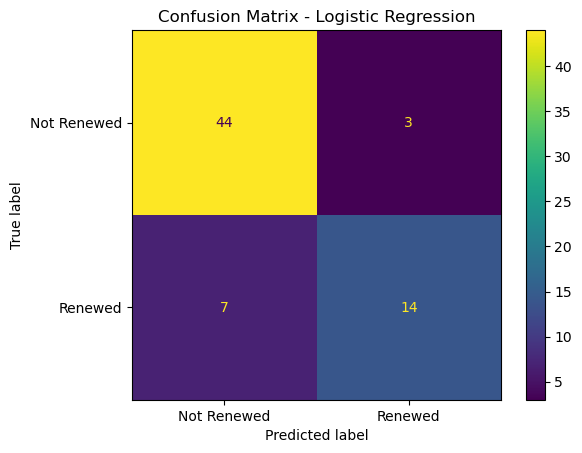

In [119]:
# Create and plot the confusion matrix using actual and predicted values using logistic regression model
cm_logistic = confusion_matrix(y_test, y_pred_logistic)

display_cm = ConfusionMatrixDisplay(
    confusion_matrix=cm_logistic,
    display_labels=["Not Renewed", "Renewed"]
)

display_cm.plot()
plt.title("Confusion Matrix - Logistic Regression")
plt.show()

Step 9: Building SVM as a Comparison Model

In [120]:
# Import Support Vector Classifier from scikit-learn
from sklearn.svm import SVC

In [121]:
# Create an SVM classification model
svm_model = SVC(random_state=42)  

In [122]:
# Train the SVM model using the preprocessed training data
svm_model.fit(X_train_preprocessed, y_train)  
print("SVM model trained successfully!")

SVM model trained successfully!


In [123]:
# Use the trained SVM model to predict values for the test data
y_pred_svm = svm_model.predict(X_test_preprocessed)  
print("SVM predictions completed successfully!")

SVM predictions completed successfully!


In [124]:
# Display the first 10 predicted values from the SVM model
print("First 10 SVM predictions:")
print(y_pred_svm[:10])  

First 10 SVM predictions:
[1 1 0 0 0 0 0 0 0 0]


In [125]:
# Create a DataFrame to compare actual and predicted values using SVM model
svm_comparison_df = pd.DataFrame({
    "Actual": y_test.values,  
    "SVM_Predicted": y_pred_svm
})

display(svm_comparison_df.head(10)) 

,Actual,SVM_Predicted
0,1,1
1,1,1
2,0,0
3,0,0
4,0,0
5,0,0
6,0,0
7,0,0
8,0,0
9,0,0


Step 10: Evaluating SVM model

In [126]:
# Evaluating SVM model
accuracy_svm = accuracy_score(y_test, y_pred_svm)  # Calculate the accuracy of the SVM model
precision_svm = precision_score(y_test, y_pred_svm)  # Calculate the precision of the SVM model
recall_svm = recall_score(y_test, y_pred_svm)  # Calculate the recall of the SVM model
f1_svm = f1_score(y_test, y_pred_svm)  # Calculate the F1-score of the SVM model

print("SVM Evaluation Metrics:")  
print("Accuracy:", accuracy_svm)
print("Precision:", precision_svm)
print("Recall:", recall_svm)
print("F1-score:", f1_svm)

SVM Evaluation Metrics:
Accuracy: 0.8382352941176471
Precision: 0.8571428571428571
Recall: 0.5714285714285714
F1-score: 0.6857142857142857


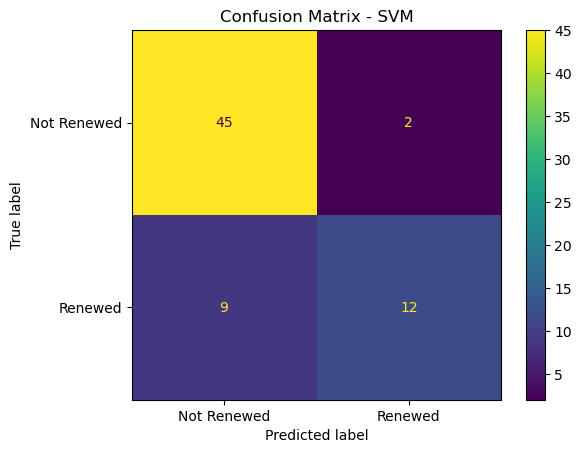

In [127]:
# Create and plot the confusion matrix using actual and predicted values using SVM model
cm_svm = confusion_matrix(y_test, y_pred_svm)

display_cm_svm = ConfusionMatrixDisplay(  
    confusion_matrix=cm_svm, 
    display_labels=["Not Renewed", "Renewed"]  
)  

display_cm_svm.plot() 
plt.title("Confusion Matrix - SVM")
plt.show() 


Model Comparison

In [128]:
# Model comparison in table
model_comparison_df = pd.DataFrame({  
    "Model": ["Logistic Regression", "SVM"],  
    "Accuracy": [accuracy_logistic, accuracy_svm],  
    "Precision": [precision_logistic, precision_svm],  
    "Recall": [recall_logistic, recall_svm],  
    "F1-score": [f1_logistic, f1_svm]  
})  

display(model_comparison_df) 

,Model,Accuracy,Precision,Recall,F1-score
0,Logistic Regression,0.852941,0.823529,0.666667,0.736842
1,SVM,0.838235,0.857143,0.571429,0.685714


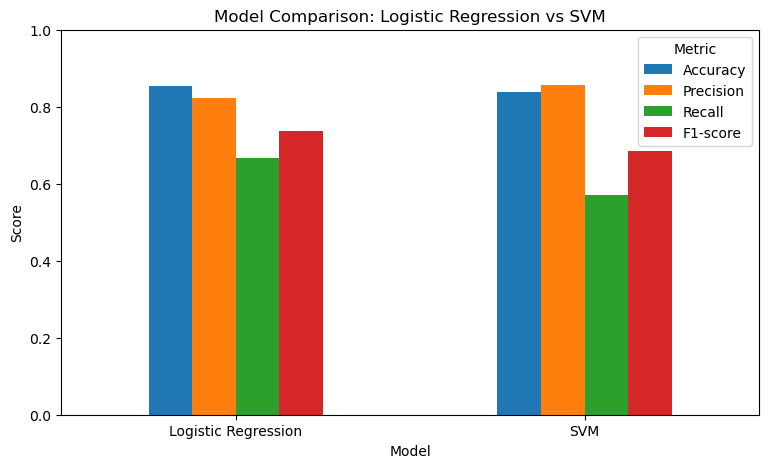

In [129]:
# Model comparison in chart
model_comparison_df.set_index("Model").plot(kind="bar", figsize=(9, 5)) 

plt.title("Model Comparison: Logistic Regression vs SVM")
plt.xlabel("Model")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.legend(title="Metric")

plt.show()  # Display the chart

Task 2: Compare the results and interpret them

In [130]:
print("Which model performed better?")
print("Based on the evaluation metrics shown in the chart, Logistic Regression performed slightly"
      "\nbetter overall compared to SVM. Logistic Regression achieved higher accuracy, recall, and"
      "\nF1-score, while SVM obtained slightly better precision. However, Logistic Regression"
      "\ndemonstrated a more balanced performance across most evaluation metrics, particularly in"
      "\nrecall and F1-score, which are important for identifying customers who are likely to renew"
     "\ntheir insurance policies. Therefore, Logistic Regression is recommended as the better-"
     "\nperforming model for the insurance renewal dataset.")

print("\nWhich metric is most important for your business problem?")
print("For the insurance policy renewal prediction, the most important evaluation metric"
      "\nis Recall. Recall measures how many customers who actually renewed their insurance"
      "\npolicies were correctly identified by the model. A higher recall means the model is able to"
      "\nsuccessfully find more potential renewing customers. This is important because the"
     "\ncompany can use this information to strengthen customer relationships, improve retention"
     "\nstrategies, and provide better customer support to clients who are likely to renew their"
     "\npolicies")

print("\nWhat do false positives and false negatives mean in your dataset?")
print("False positives mean that the model predicts that a customer will renew their insurance"
     "\npolicy, but the customer actually does not renew. On the other hand, false negatives occur"
     "\nwhen the model predicts that a customer will not renew their policy, but the customer"
     "\nactually renews it. These prediction errors are important because they may affect business"
     "\ndecisions, customer retention strategies, and marketing efforts.")

print("\nWhat is one possible limitation or bias in your model?")
print("One possible limitation or bias in the model is that features such as Age, Annual_Premium,"
     "\nYears_With_Company, Satisfaction_Score, and Number_of_Claims may influence the"
     "\npredictions in ways that could unfairly favor or disadvantage certain groups of customers."
     "\nAs a result, the model may not always provide completely fair or unbiased predictions for"
     "\nall customers. Therefore, the model should be used carefully and supported with human"
     "\njudgment before making important business decisions.")

print("\nWhy should human judgment still be used?")
print("Human judgment should still be used because the dataset may not fully represent all"
     "\ncustomer characteristics or behaviors. For example, factors such as financial capacity or"
     "\nincome, the number of existing insurance policies, and a customer’s willingness to"
     "\nmaintain multiple policies are not included in the dataset. These missing features may affect"
     "\nthe accuracy and fairness of the model’s predictions. Therefore, human review is still"
     "\nimportant to consider real-world situations and make more informed and responsible"
     "\nbusiness decisions.")

Which model performed better?
Based on the evaluation metrics shown in the chart, Logistic Regression performed slightly
better overall compared to SVM. Logistic Regression achieved higher accuracy, recall, and
F1-score, while SVM obtained slightly better precision. However, Logistic Regression
demonstrated a more balanced performance across most evaluation metrics, particularly in
recall and F1-score, which are important for identifying customers who are likely to renew
their insurance policies. Therefore, Logistic Regression is recommended as the better-
performing model for the insurance renewal dataset.

Which metric is most important for your business problem?
For the insurance policy renewal prediction, the most important evaluation metric
is Recall. Recall measures how many customers who actually renewed their insurance
policies were correctly identified by the model. A higher recall means the model is able to
successfully find more potential renewing customers. This is importan